In [1]:
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
import itertools, os

In [6]:
emb_path = '../data/from-hari-v3/clean_combined_campaign_features.pth'
emb = torch.load(features_path)
df_emb = pd.DataFrame(emb.numpy())
df_emb.shape

(524033, 384)

In [7]:
env_path = '../data/from-hari-v3/clean_combined_campaign_env_data.csv'
df_env = pd.read_csv(env_path)
df_env.shape

(524033, 48)

In [8]:
# merge df's 
df_merged = df_emb.merge(df_env, left_index=True, right_index=True)
df_merged.shape
# save 
save_dir = '/home/jko/ssl-cpi-analysis/data/from-hari-v3'
save_filename = 'cls_env_all_merged.parquet'
save_path = os.path.join(save_dir, save_filename)
df_merged.to_parquet(save_path, index=False)

In [7]:
# reload data to confirm
save_dir = '/home/jko/ssl-cpi-analysis/data/from-hari-v3'
save_filename = 'cls_env_all_merged.parquet'
save_path = os.path.join(save_dir, save_filename)
df_reload = pd.read_parquet(save_path)
df_merged = df_reload
df_merged.shape

(524033, 432)

UMAP hyperparameters:  
- n_neighbors
- min_dist
- metric

In [19]:
# get a balanced subset
samples_per_class = 10000
dfs = []
habit_classes = ['bullet', 'column', 'rimed']
for cls in habit_classes:
    df_cls = df_merged[df_merged['Classification'] == cls].sample(n=samples_per_class, random_state=42)
    dfs.append(df_cls)
df_balanced = pd.concat(dfs).reset_index(drop=True)

In [25]:
# subset of balanced df
n_subset = 1_000
df_subset = df_balanced.sample(n_subset)
emb_cols = [str(i) for i in range(384)]
X = df_subset[emb_cols]
n_components = 2
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

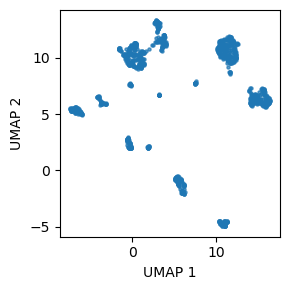

In [27]:
model = umap.UMAP()
X_umap = model.fit_transform(X_scaled)
plt.figure(figsize=(3, 3))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=5, alpha=0.7)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.tight_layout()

In [23]:
df_merged.head()

,0,1,2,3,4,5,6,7,8,9,...,Altitude [m],Pressure [hPa],Temperature [C],Ice Water Content [g/m3],PSD IWC [g/m3],concentration ratio,area ratio,mass ratio,Campaign,Perimeter [pixels]
0,1.710554,1.393568,3.177823,-0.757673,-0.633948,-0.168053,-1.560423,-1.539199,1.107319,3.162958,...,8238.878125,343.835016,-39.222314,0.041004,0.059899,0.000004,0.000129,0.000522,ARM,NaN
1,2.639770,1.870557,3.738529,-1.303642,-0.456105,0.182570,-1.645625,-1.389037,0.564212,2.378380,...,8234.885352,344.035004,-42.010040,0.027216,0.055219,0.000453,0.012640,0.018208,ARM,NaN
2,-0.739239,-0.054968,0.947078,-0.589259,1.388247,-0.067568,-1.092112,0.602213,0.591173,0.340691,...,7612.743652,376.370209,-36.774002,0.046460,0.086047,0.000000,0.000000,0.000000,ARM,NaN
3,1.567777,1.446529,2.506802,-1.067740,0.357187,0.265005,-0.560557,-1.382249,1.367496,2.629955,...,9439.850781,287.800226,-49.255927,0.027244,0.075817,0.000000,0.000000,0.000000,ARM,NaN
4,2.114330,0.976239,3.096801,-1.177441,0.075485,0.933317,-1.363156,-1.865664,0.227272,2.527692,...,7919.968848,360.108545,-39.378160,0.010284,0.017845,0.000000,0.000000,0.000000,ARM,NaN


In [44]:
# Hyperparameter grid search and save plots
best_score = -np.inf
best_params = None
labels = df_subset['Classification'].values
unique_labels, label_codes = np.unique(labels, return_inverse=True) # Map each unique label to an integer
fig_save_dir = '/home/jko/ssl-cpi-analysis/figs/umap-hyperparam-tuning-v2'
summary_save_dir = '/home/jko/ssl-cpi-analysis/data'
os.makedirs(fig_save_dir, exist_ok=True)
os.makedirs(summary_save_dir, exist_ok=True)

# Define parameter grid
param_grid = {
    'n_neighbors': [25, 50, 75, 100],
    'min_dist': [0.0, 0.2, 0.4, 0.6],
    'metric': ['euclidean', 'chebyshev', 'cosine', 'correlation']
}

param_names = list(param_grid.keys())
param_combinations = list(itertools.product(*param_grid.values()))
results = []

for i, param_tuple in enumerate(param_combinations):
    params = dict(zip(param_names, param_tuple))
    reducer = umap.UMAP(
        n_neighbors=params['n_neighbors'],
        min_dist=params['min_dist'],
        metric=params['metric'],
        n_jobs=-1
    )
    embedding = reducer.fit_transform(X_scaled)
    
    # evaluate and plot
    # eval on 'true' labels
    score = silhouette_score(embedding, labels)
    print(f"Params: {params}, Silhouette Score: {score:.3f}")
    if score > best_score:
        best_score = score
        best_params = params

    # Save results for DataFrame
    result_row = params.copy()
    result_row['silhouette_score'] = score
    results.append(result_row)

    # Save scatter plot
    plt.figure(figsize=(5, 5))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=label_codes, s=5, alpha=0.7, cmap='tab10')
    plt.title(f"UMAP: {params}\nSilhouette Score: {score:.3f}")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.tight_layout()
    fname = f"umap_scatter_{i}_nn{params['n_neighbors']}_md{params['min_dist']}_metric{params['metric']}.png"
    savepath = os.path.join(fig_save_dir, fname)
    plt.savefig(savepath)
    plt.close()

print("Best parameter combination:", best_params)
print("Best silhouette score:", best_score)

# Save summary DataFrame as CSV
results_df = pd.DataFrame(results)
csv_save_path = os.path.join(summary_save_dir, "umap_hyperparam_summary_v2.csv")
results_df.to_csv(csv_save_path, index=False)

Params: {'n_neighbors': 25, 'min_dist': 0.0, 'metric': 'euclidean'}, Silhouette Score: 0.342
Params: {'n_neighbors': 25, 'min_dist': 0.0, 'metric': 'chebyshev'}, Silhouette Score: 0.349
Params: {'n_neighbors': 25, 'min_dist': 0.0, 'metric': 'cosine'}, Silhouette Score: 0.343
Params: {'n_neighbors': 25, 'min_dist': 0.0, 'metric': 'correlation'}, Silhouette Score: 0.293
Params: {'n_neighbors': 25, 'min_dist': 0.2, 'metric': 'euclidean'}, Silhouette Score: 0.297
Params: {'n_neighbors': 25, 'min_dist': 0.2, 'metric': 'chebyshev'}, Silhouette Score: 0.301
Params: {'n_neighbors': 25, 'min_dist': 0.2, 'metric': 'cosine'}, Silhouette Score: 0.323
Params: {'n_neighbors': 25, 'min_dist': 0.2, 'metric': 'correlation'}, Silhouette Score: 0.298
Params: {'n_neighbors': 25, 'min_dist': 0.4, 'metric': 'euclidean'}, Silhouette Score: 0.280
Params: {'n_neighbors': 25, 'min_dist': 0.4, 'metric': 'chebyshev'}, Silhouette Score: 0.300
Params: {'n_neighbors': 25, 'min_dist': 0.4, 'metric': 'cosine'}, Silhou

In [ ]:
from sklearn.metrics import silhouette_score

X = df.iloc[:, :384].values  # embeddings
labels = df['Classification'].values  # true class labels

score = silhouette_score(X, labels)
print(f"Silhouette score (using true labels): {score:.3f}")

Examine sensitivities to hyperparameters

In [2]:
df = pd.read_csv('/home/jko/ssl-cpi-analysis/data/umap_hyperparam_summary_v2.csv')
df.head()

,n_neighbors,min_dist,metric,silhouette_score
0,25,0.0,euclidean,0.341910
1,25,0.0,chebyshev,0.349340
2,25,0.0,cosine,0.343246
3,25,0.0,correlation,0.293102
4,25,0.2,euclidean,0.297290


<Figure size 600x400 with 0 Axes>

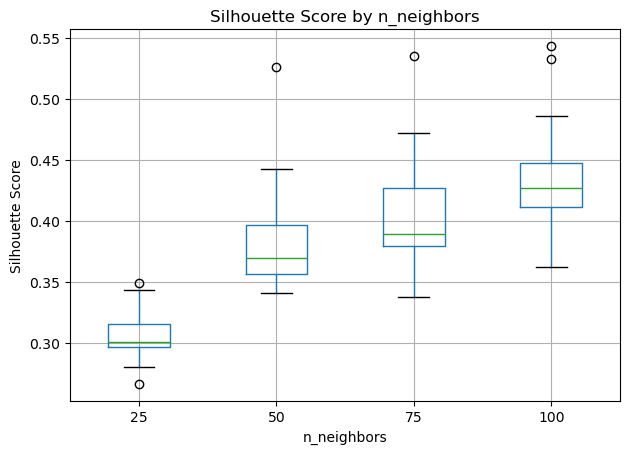

<Figure size 600x400 with 0 Axes>

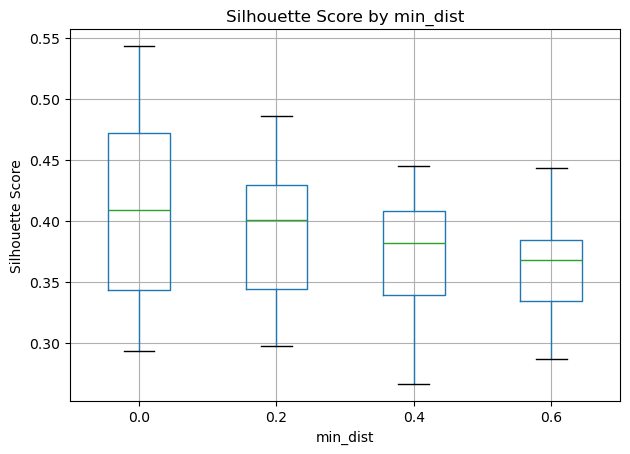

<Figure size 800x400 with 0 Axes>

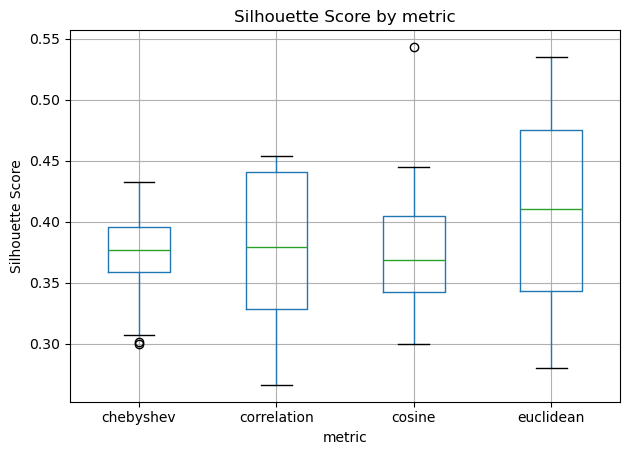

In [3]:
# (1) Boxplot for each unique value of n_neighbors
plt.figure(figsize=(6,4))
df.boxplot(column='silhouette_score', by='n_neighbors')
plt.title('Silhouette Score by n_neighbors')
plt.suptitle('')
plt.xlabel('n_neighbors')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# (2) Boxplot for each unique value of min_dist
plt.figure(figsize=(6,4))
df.boxplot(column='silhouette_score', by='min_dist')
plt.title('Silhouette Score by min_dist')
plt.suptitle('')
plt.xlabel('min_dist')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# (3) Boxplot for each unique value of metric
plt.figure(figsize=(8,4))
df.boxplot(column='silhouette_score', by='metric')
plt.title('Silhouette Score by metric')
plt.suptitle('')
plt.xlabel('metric')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

In [6]:
# print top-5 param sets
df_sorted = df.sort_values(by='silhouette_score', ascending=False)
df_sorted.head()

,n_neighbors,min_dist,metric,silhouette_score
50,100,0.0,cosine,0.542973
32,75,0.0,euclidean,0.534870
48,100,0.0,euclidean,0.532789
16,50,0.0,euclidean,0.525991
52,100,0.2,euclidean,0.485776


In [10]:
print(list(df_merged.columns))

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '15